In [2]:
%matplotlib notebook

import math
import json
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from mercury import lrm as lrmodel
from mercury import rec as Mercury
import mercury

In [4]:
# define a few standard response profiles
def hypsecant(x):
    return 1./math.cosh(x*1.5)

def logistic(x):
    ch = 1./math.cosh(x)
    return ch*ch

def gauss(x):
    return math.exp(-x*x)

def cauchy(x):
    return 1/(x*x+1)
   
vhypsecant = np.vectorize(hypsecant)
vlogistic = np.vectorize(logistic)
vgauss = np.vectorize(gauss)
vcauchy = np.vectorize(cauchy)

In [5]:
# functions for making a sensor array
def mkrectarray(cols, rows, pitch=1):
    x = np.linspace(-cols*0.5, cols*0.5, cols)
    y = np.linspace(-rows*0.5, rows*0.5, rows)
    X, Y = np.meshgrid(x*pitch, y*pitch)
    return X.flatten(), Y.flatten()

def mkhexarray(rings, pitch=1, rmax=-1):
    xy = [0]  
    rot60 = np.exp((np.pi/3)*1j)
    vec = rot60*rot60
    for n in range(1, rings+1):
        val = n
        for i in range(6):
            for k in range(n):
                if rmax<0 or np.abs(val)*pitch<=rmax: 
                    xy.append(val)
                val += vec
            vec *= rot60
    return np.real(xy)*pitch, np.imag(xy)*pitch

In [6]:
# functions for making flood and test data
def mkrectflood(dx, dy, n):
    x = (np.random.rand(n)-0.5)*dx
    y = (np.random.rand(n)-0.5)*dy
    return x,y

def mkroundflood(rmax, n):
    theta = np.random.rand(n)*(2*np.pi)
    r = np.sqrt(np.random.rand(n))*rmax
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x,y
    
def mkdata(X, Y, x, y, gain, vfunc):    
    data = vfunc(np.hypot(x-X[0], y-Y[0]))
    for ip in range(1,len(X)):
        data = np.vstack((data, vfunc(np.hypot(x-X[ip], y-Y[ip]))))
    return np.random.poisson(np.transpose(data)*gain)

In [7]:
# create the sensor array, flood and test data

X, Y = mkhexarray(4)             # create the sensor array
xf, yf = mkroundflood(4.2,10000) # create an array of flood positions
x, y = mkroundflood(4.2,10000)   # create an array of test positions

flood = mkdata(X, Y, xf, yf, 100, vgauss) # use gain=100 and Gaussian response profile
data = mkdata(X, Y, x, y, 100, vgauss)

In [8]:
# Ready to create a light response model (LRM)
# Choose LRF type here
lrftype = 'Axial'
#lrftype = 'XY'

In [9]:
if lrftype == 'Axial':
    # create a JSON template for ana axial LRF object
    lrf = json.loads('{"type": "Axial", "rmin": 0, "rmax": 8, "nint": 15, "x0": 0, "y0": 0}')
    cmp = json.loads('{"method": "dualslope", "k": 5, "lam": 0.5, "r0": 1}')
    lrf['compression'] = cmp
    cstr = json.loads('["non-negative", "non-increasing", "flattop"]')
    lrf['constraints'] = cstr

    # create a new LRM object and fill it with the sensor positions
    Nsens = len(X)
    lrm = lrmodel.LRModel(Nsens)
    for i in range(0,Nsens):
        lrm.AddSensor(i, X[i], Y[i])
    # PMT coordinates must be set as the LRF center       
        lrf['x0'] = X[i]
        lrf['y0'] = Y[i]
    # rmax is extended to cover the whole detector area    
        r = math.sqrt(X[i]*X[i] + Y[i]*Y[i])
        lrf['rmax'] = 4 + r
        lrm.SetLRF(i, json.dumps(lrf))
        
if lrftype == 'XY':
    # create a JSON template for an XY LRF object
    lrf = json.loads('{"type": "XY", "xmin": -4, "xmax": 4, "nintx": 15, "ymin": -4, "ymax": 4, "ninty": 15}')
    cstr = json.loads('["non-negative"]')
    lrf['constraints'] = cstr

    # create a new LRM object and fill it with the sensor positions
    Nsens = len(X)
    lrm = lrmodel.LRModel(Nsens)
    for i in range(0,Nsens):
        lrm.AddSensor(i, X[i], Y[i])
        lrm.SetLRF(i, json.dumps(lrf))  

In [10]:
# Prepare LRM for reconstruction: fit sensor responses 
lrm.ClearAllFitData()
xyz = np.vstack((xf, yf, np.zeros(10000)))
for i in range(Nsens):
    xyza = np.transpose(np.vstack((xyz, flood[:,i])))
    lrm.AddFitData(i, xyza)
    lrm.FitSensor(i)

<IPython.core.display.Javascript object>


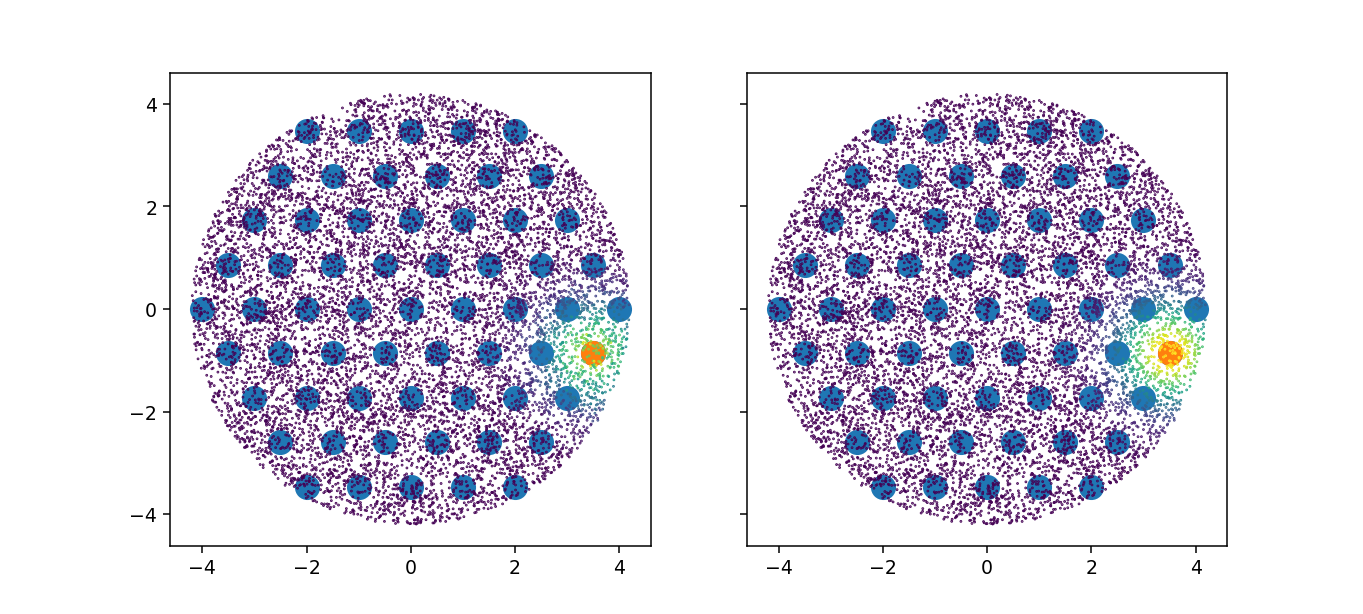

In [12]:
# Verify quality of the fit
# Left: flood, right: LRF calculated at the flood positions
ip = 60 # choose the sensor to plot
fig1, axes1 = plt.subplots(nrows=1, ncols=2, figsize=(10, 4.5), sharey=True)
axes1[0].scatter(X, Y, s=150)
axes1[0].scatter(X[ip], Y[ip], s=150)
axes1[0].scatter(xf, yf, s=0.2, c=flood[:,ip])

t = np.zeros(10000)
for i in range(10000):
    t[i] = lrm.Eval(ip, xf[i], yf[i], 0)

axes1[1].scatter(X, Y, s=150)
axes1[1].scatter(X[ip], Y[ip], s=150)
axes1[1].scatter(xf, yf, s=0.2, c=t)   

In [13]:
# create and tune a single-threaded ML reconstructor
recml = Mercury.RecML(lrm.ModelAsJson())
recml.setCogRelCutoff(0.1)
recml.setRecCutoffRadius(2.5)
recml.setRMstepX(0.1)
recml.setRMstepY(0.1)
recml.setMinuitVerbosity(2)

# reconstruct one event and read the result
evt = 2
sat = data[evt]<0
recml.ProcessEvent(data[evt], sat)
statml = recml.getRecStatus()
xml = recml.getRecX()
yml = recml.getRecY()
eml = recml.getRecE()
chi2ml = recml.getChi2Min()

# print the result
print ('Event #', evt)
print ('True position:', x[evt], y[evt])
print ('Init. guess:', recml.getGuessX(), recml.getGuessY())
print ('Rec. status:', statml)
print ('Rec. position:', xml, yml)
print ('Reduced chi2:', chi2ml)

Event # 2
True position: 0.646724841632911 -0.1046913354110434
Init. guess: 0.6891495601173019 -0.10666588551010686
Rec. status: 0
Rec. position: 0.6869920027874308 -0.14660904247846943
Reduced chi2: 23.823277655031458
Minuit2Minimizer: Minimize with max-calls 500 convergence for edm < 0.001 strategy 1
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = -974.994540867157411
Edm   = 2.86918760099575744e-07
Nfcn  = 43
x	  = 0.686992	 +/-  0.0513259
y	  = -0.146609	 +/-  0.0530631
z	  = 0	 (fixed)
e	  = 1.02577	 +/-  0.0753711	(limited)


[Info] MnSeedGenerator Initial state: FCN =      -974.4258262 Edm =      0.5687853222 NCalls =     13
[Info] VariableMetricBuilder Start iterating until Edm is < 2e-06 with call limit = 500
[Info] VariableMetricBuilder    0 - FCN =      -974.4258262 Edm =      0.5687853222 NCalls =     13
[Info] VariableMetricBuilder    1 - FCN =      -974.9933683 Edm =    0.001198478621 NCalls =     20
[Info] VariableMetricBuilder    2 - FCN =      -974.9945409 Edm =   2.889538426e-07 NCalls =     27
[Info] VariableMetricBuilder After Hessian
[Info] VariableMetricBuilder    3 - FCN =      -974.9945409 Edm =   2.869187601e-07 NCalls =     43
[Info] Minuit2Minimizer::Hesse Using max-calls 500
[Info] Minuit2Minimizer::Hesse Hesse is valid - matrix is accurate


In [14]:
# create and tune batch parallel ML reconstructor with 3 threads
recmlmt = Mercury.RecML_MP(lrm.ModelAsJson(), 3)
recmlmt.setCogRelCutoff(0.3)
recmlmt.setRecCutoffRadius(2.5)
recmlmt.setRMstepX(0.1)
recmlmt.setRMstepY(0.1)
recmlmt.setRMmaxFuncCalls(500)

# reconstruct all the events by multithreaded ML
sat = data<0
recmlmt.ProcessEvents(data, sat)
statml = np.array(recmlmt.getRecStatus())
xml = np.array(recmlmt.getRecX())
yml = np.array(recmlmt.getRecY())
eml = np.array(recmlmt.getRecE())
chi2ml = np.array(recmlmt.getChi2Min())

<IPython.core.display.Javascript object>


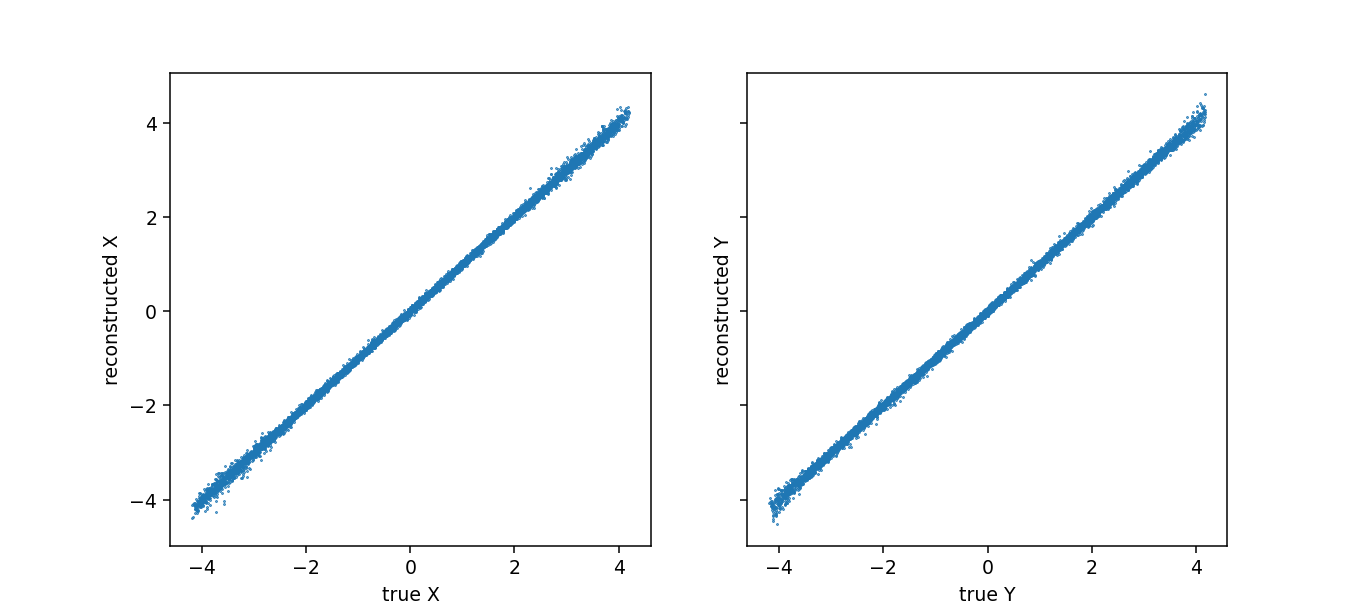

Text(0, 0.5, 'reconstructed Y')

In [15]:
# Verify reconstruction
fig2, axes2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 4.5), sharey=True)
cut = (statml == 0) & (np.abs(xml)<10) & (np.abs(yml)<10)
axes2[0].scatter(x[cut], xml[cut], s=0.2)
axes2[1].scatter(y[cut], yml[cut], s=0.2)
axes2[0].set_xlabel('true X')
axes2[0].set_ylabel('reconstructed X')
axes2[1].set_xlabel('true Y')
axes2[1].set_ylabel('reconstructed Y')